# Filamentation 1030 nm / 13 µJ -- expérience Tokyo

Ce notebook utilise **le paquet `sim/` du dépôt** (`filament_sim.run`,
`figures_filament`, `figures_article`), pas le script monolithique
`NewSim3juillet.py`. Trois raisons concrètes, pas cosmétiques :

1. **La géométrie de cette expérience est déjà codée dans `Config`.**
   Le champ `z_focus_air_um` calcule `begin = -n0 · z_focus_air_um`, et son
   commentaire cite explicitement ton `unified_filament_slider_v3.py`
   (« this is the same rule already used by unified_filament_slider_v3.py »).
   Plus besoin de coder la réfraction à la main.

2. **La convention d'énergie est différente -- et c'est un piège.**
   `NewSim3juillet.py` utilise `I0 = 2E/(π w0² Δt)`, qui traite `Δt` comme une
   durée flat-top : il fallait diviser l'énergie par 1.0645 avant de la passer.
   Le `Config` du dépôt fait **déjà** la correction en interne
   (`P_in = E/(t_p·√(π/2))`, avec le commentaire « overstates the pulse energy
   by 1.0644, i.e. +6.4% »). Donc ici on passe l'énergie **physique vraie**
   (12.561 µJ), *pas* la valeur réduite 11.801. Passer 11.801 sous-estimerait
   l'énergie de 6.4 %.

3. **Le bug `T_op` que j'avais signalé n'existe pas dans ce solveur.**
   `sim/grids.py` a `enable_spectral_filter=True` par défaut, qui masque la
   zone où `T_op < 0` (fréquence absolue négative). Il a en plus
   `enable_space_time_focusing` et les 6 interrupteurs fins de l'éq. (3) du
   rapport, absents de `NewSim3juillet.py`.

**Bonus** : contrairement à `NewSim3juillet.py` (dont `_record()` n'assigne
jamais `E_plasma_z`/`E_MPI_z`), le solveur du dépôt calcule réellement les
pertes d'énergie cumulées -> la figure style Fig. 12 est disponible ici.

## Installation des dépendances

À exécuter en premier. Le post-traitement ne demande que numpy / scipy / matplotlib ; `cupy` n'est nécessaire que pour lancer un nouveau calcul sur GPU.


In [ ]:
# [deps-install-cell]
# ============================================================================
#  Installation des dependances
# ============================================================================
# A executer une fois, en premier. Si cupy est installe par cette cellule,
# REDEMARRER LE NOYAU avant de continuer.
#
# Deux niveaux :
#   - CPU  : numpy / scipy / matplotlib (+ pillow). Suffisent pour tout
#            le POST-TRAITEMENT, c'est-a-dire relire un result.npz deja calcule
#            et regenerer les figures.
#   - GPU  : cupy. Necessaire uniquement pour LANCER un calcul
#            (filament_sim.run()), qui est un solveur CUDA.
import importlib
import importlib.util
import re
import shutil
import subprocess
import sys

REQUIRED = ["numpy", "scipy", "matplotlib", "pillow"]
_IMPORT_NAME = {"pillow": "PIL", "ipywidgets": "ipywidgets"}


def _pip(*args):
    print("  pip install", *args)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


print("Dependances CPU :")
for pkg in REQUIRED:
    mod = _IMPORT_NAME.get(pkg, pkg)
    if importlib.util.find_spec(mod) is None:
        _pip(pkg)
    else:
        print(f"  {pkg:12s} deja present")

print("\nDependance GPU (cupy) :")
if importlib.util.find_spec("cupy") is not None:
    import cupy
    print(f"  cupy {cupy.__version__} deja present")
    try:
        print(f"  GPU visible : {cupy.cuda.runtime.getDeviceCount()} device(s)")
    except Exception as exc:
        print(f"  /!\\ cupy importe mais aucun GPU utilisable ({type(exc).__name__})")
else:
    # La roue cupy depend de la version de CUDA du pilote : il n'existe pas de
    # paquet "cupy" generique qui marche partout, d'ou la detection.
    cuda_major = None
    if shutil.which("nvidia-smi"):
        try:
            out = subprocess.check_output(["nvidia-smi"], text=True)
            m = re.search(r"CUDA Version:\s*(\d+)\.", out)
            cuda_major = int(m.group(1)) if m else None
        except Exception:
            pass
    if cuda_major is None:
        print("  aucun GPU NVIDIA detecte -> cupy N'EST PAS installe.")
        print("  Le post-traitement fonctionne quand meme sur un result.npz")
        print("  deja calcule ; seul filament_sim.run() a besoin du GPU.")
    else:
        _pip(f"cupy-cuda{12 if cuda_major >= 12 else 11}x")
        print("  cupy installe -> REDEMARRER LE NOYAU avant de continuer.")

print("\nVersions :")
for _m in ("numpy", "scipy", "matplotlib"):
    try:
        print(f"  {_m:12s} {importlib.import_module(_m).__version__}")
    except ImportError:
        print(f"  {_m:12s} ABSENT")


In [1]:
import sys, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c as c_SI, epsilon_0, m_e, elementary_charge as q_e

# --- localisation des modules du depot ------------------------------------
# Ce notebook a besoin de l'arborescence "deliverable (3)/{sim,web,notebooks}",
# pas seulement du fichier .ipynb. On cherche sim/ depuis le repertoire courant
# puis en remontant, ce qui marche que le noyau soit lance depuis notebooks/,
# depuis la racine du depot, ou ailleurs.
SIM_DIR = None   # <- mettre ici le chemin de sim/ si la recherche echoue


def _resolve_pkg_dirs(explicit=None):
    roots = []
    if explicit:
        p = Path(explicit).expanduser().resolve()
        roots.append(p.parent if p.name == "sim" else p)
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        roots += [base, base / "deliverable (3)",
                  base / ".github" / "deliverable (3)"]
    for root in roots:
        if (root / "sim" / "filament_sim.py").is_file():
            return {n: root / n for n in ("sim", "web") if (root / n).is_dir()}
    return {}


_dirs = _resolve_pkg_dirs(SIM_DIR)
if not _dirs:
    raise ModuleNotFoundError(
        "dossier sim/ introuvable."
        "\n  repertoire courant : " + str(Path.cwd()) +
        "\n  Ce notebook a besoin de l'arborescence complete du depot, pas"
        "\n  seulement du .ipynb. Recupere le dossier 'deliverable (3)' entier"
        "\n  (sim/, web/, notebooks/) et lance le noyau depuis"
        "\n  'deliverable (3)/notebooks/', ou renseigne SIM_DIR ci-dessus.")
for _n, _d in _dirs.items():
    sys.path.insert(0, str(_d))
print("modules du depot :", _dirs["sim"])

# --- fonctions du depot ---
from filament_sim import run, FIELD_TOGGLES, n_sellmeier
from figures_filament import (
    load_scenario_npz, z_um_of, onaxis_index,
    critical_power, entrance_radius, marburger_collapse, count_refocusing_cycles,
    plot_fig7_fluence_contours, plot_fig8_peak_intensity,
    plot_fig9_electron_density, plot_fig12_energy_losses,
    plot_fig13_free_vs_trapped, plot_free_vs_trapped_vs_z,
    plot_scenario_summary, fluence_level_extent, run_health_check,
)

OUT_ROOT = Path("runs_1030nm"); OUT_ROOT.mkdir(exist_ok=True)
FIG_DIR = OUT_ROOT / "figures_for_report"; FIG_DIR.mkdir(exist_ok=True)
print("FIELD_TOGGLES:", FIELD_TOGGLES)

FIELD_TOGGLES: ['enable_kerr_instantaneous', 'enable_kerr_raman', 'enable_self_steepening', 'enable_photoionization_loss', 'enable_plasma_defocusing', 'enable_plasma_absorption']


## 1. Paramètres d'entrée

### Géométrie -- déléguée à `Config.z_focus_air_um`
Le profilomètre mesure le foyer à **272 µm** de la face d'entrée *côté air*.
La réfraction paraxiale à une interface plane conserve le waist `w0` et ne
change que la distance focale (×`n0`). On passe donc `z_focus_air_um=272.0`
et `Config` en déduit `begin = -n0 × 272 µm = -394.4 µm`.

### Énergie -- valeur physique vraie
13.0 µJ incidents → Fresnel (96.63 %) → **12.561 µJ dans le verre**, passés
tels quels à `run()` (voir l'encadré en tête : la correction gaussienne est
déjà dans `Config`).

Contrôle au lancement : `[init] U_beam(0)` doit afficher **≈ 12.56 µJ**.

### `n2` -- le dépôt documente déjà le point
`figures_article.Params` porte le commentaire `n2: 3.54e-20 — défaut de run()
(le notebook ne le surcharge pas)` : le dépôt sait donc déjà que `run()`
impose 3.54e-20 (valeur Couairon 2005 **à 800 nm**) quand on ne dit rien.
Comme l'expérience est à 1030 nm, les trois candidates sont gardées.

| n2 (m²/W) | source | P_cr |
|---|---|---|
| 2.40e-20 | Milam 1998, 800 nm | 4.57 MW |
| **2.74e-20** | Milam 1998, **1053 nm** (retenu) | **4.01 MW** |
| 3.54e-20 | Couairon 2005, 800 nm (défaut `run()`) | 3.10 MW |

La ligne retenue redonne le `P_cr ≈ 4.0 MW` déjà annoncé §8 du rapport.

In [2]:
# ================= PARAMETRES D'ENTREE =================
# --- geometrie (mesuree cote air ; Config applique la refraction) ---
Z_FOCUS_AIR_UM = 272.0
END_M          = 800e-6

# --- laser ---
WAVELENGTH_M    = 1030e-9
ENERGY_INPUT_UJ = 13.0        # avant l'interface
W0_M            = 3e-6        # waist AU FOYER (inchange par la refraction)
DELTA_T_S       = 263e-15     # FWHM en intensite

TRANSMISSION    = 1.0 - ((1.45 - 1.0) / (1.45 + 1.0))**2      # Fresnel, incidence normale
ENERGY_IN_GLASS = ENERGY_INPUT_UJ * TRANSMISSION              # 12.561 uJ -> passe TEL QUEL

# --- materiau SiO2 (source de chaque valeur en commentaire) ---
N2_MILAM_800  = 2.40e-20   # Milam 1998 @800nm
N2_MILAM_1053 = 2.74e-20   # Milam 1998 @1053nm  <- le plus proche de 1030 nm
N2_COUAIRON   = 3.54e-20   # Couairon 2005 @800nm (defaut de run())
N2_CHOSEN     = N2_MILAM_1053

UI_EV       = 9.0        # gap SiO2         -- Couairon 2005 / Bulgakova 2010
MEFF_REL    = 0.64       # masse Keldysh    -- Couairon 2005
TAU_C_S     = 1.7e-15    # -> omega0*tau_c = 3.1 a 1030 nm (convention Bulgakova ;
                          #    Couairon utilise 1e-14 -> 23.6). Defaut du depot.
TAU_R_S     = 330e-15    # piegeage STE     -- Mouskeftaras 2013 / Tsaturyan 2025
RHO_MAX_CM3 = 2.1e22     # densite d'atomes -- Couairon 2005
US_EV       = 6.0        # re-ionisation STE-- Chimier PRB 2011
F_R, TAU_D_S, TAU_S_S = 0.18, 32e-15, 12e-15   # Raman -- Couairon 2005
LAMBDA_PROBE_M = 490e-9

# --- grille ---
NT = 4096       # cf. section 2 : Nt=2000 de l'ancien notebook etait trop serre
NR = 3001       # ordre Hankel -> 3000 points radiaux
R_FACTOR = 90.0
SAVE_STRIDE, RHO_T_STRIDE, RHO_R_STRIDE = 100, 20, 4

# begin est calcule par Config, mais on le reproduit ici pour dimensionner Nz
n0 = n_sellmeier(WAVELENGTH_M)
BEGIN_M = -n0 * Z_FOCUS_AIR_UM * 1e-6
LZ = END_M - BEGIN_M
NZ = int(LZ / 24e-9)

k0 = 2*np.pi*n0/WAVELENGTH_M
Z_R_FOCAL = k0*W0_M**2/2
W_ENTRANCE_M = entrance_radius(W0_M, BEGIN_M, WAVELENGTH_M, n0)

print(f"n0(1030nm)        = {n0:.5f}   (Sellmeier ; le slider suppose 1.45 -> accord 0.003%)")
print(f"begin             = {BEGIN_M*1e6:+.2f} um   (= -n0 x {Z_FOCUS_AIR_UM:.0f} um, calcule par Config)")
print(f"boite             = [{BEGIN_M*1e6:+.1f}, {END_M*1e6:+.1f}] um   Nz={NZ}  dz={LZ/NZ*1e9:.2f} nm")
print(f"energie           = {ENERGY_INPUT_UJ:.1f} uJ -> {ENERGY_IN_GLASS:.3f} uJ (T={TRANSMISSION*100:.2f}%)")
print(f"                    passee TELLE QUELLE a run() (Config fait deja la correction gaussienne)")
print(f"z_R au foyer      = {Z_R_FOCAL*1e6:.2f} um")
print(f"rayon a l'ENTREE  = {W_ENTRANCE_M*1e6:.2f} um   (x{W_ENTRANCE_M/W0_M:.1f} le waist focal)")

n0(1030nm)        = 1.45004   (Sellmeier ; le slider suppose 1.45 -> accord 0.003%)
begin             = -394.41 um   (= -n0 x 272 um, calcule par Config)
boite             = [-394.4, +800.0] um   Nz=49767  dz=24.00 nm
energie           = 13.0 uJ -> 12.561 uJ (T=96.63%)
                    passee TELLE QUELLE a run() (Config fait deja la correction gaussienne)
z_R au foyer      = 39.80 um
rayon a l'ENTREE  = 29.88 um   (x10.0 le waist focal)


## 1bis. Vérifier `w0` sur la caustique mesurée

`../../beam profile to fit/` contient 17 images 200×200 (caméra 10 bits) de
z = −9300 à −7300. `fit_beam_profile` ajuste une gaussienne 2D sur chacune,
puis la caustique `w(z) = w0√(1+((z−z0)/zR)²)`.

**Deux résultats à lire séparément.**

### (0) Contrôle préalable : la densité optique a changé pendant le scan
Les caustiques ont été prises avec un filtre de densité ajusté « plus ou moins »
pour éviter la saturation. Une atténuation **uniforme** est inoffensive : elle
ne change ni la largeur ajustée ni le rapport `A_eff/A_gauss`, tous deux
invariants d'échelle. Mais un **changement** d'atténuation entre images, si.

`power_consistency()` teste `A·w²` (puissance totale de la gaussienne), qui doit
être constant à densité fixe. Résultat : **plateau à ±1.1 % de z = −8700 à
−7900**, et hors de là ça dérive fort (−28 % à +214 %, plus la frame saturée
à −7300). **Seules 9 images sur 17 sont exploitables.**

### (i) La caustique n'est pas gaussienne — mais d'un facteur ~2, pas ~12
Le test de symétrie compare `w²−w0²` à ±dz du minimum ; une gaussienne donne
**1.00**. Sur les seules images cohérentes :

| ±dz | rapport |
|---|---|
| 300 µm | **2.08** |
| 400 µm | **3.06** |

Les valeurs à ±500/600/800 (jusqu'à 12.4) reposaient sur des images écartées par
le contrôle de puissance — elles ne sont **pas** exploitables. L'asymétrie reste
réelle et significative (2–3 au lieu de 1.00), mais bien moins spectaculaire
qu'annoncé d'abord. Le faisceau diverge plus vite après le foyer qu'il ne
converge avant.

C'est une **limite du modèle**, pas un réglage : `envelope_gaussian_focused`
suppose une gaussienne parfaite. Un foyer aberré étale l'énergie et a une
intensité crête plus basse qu'une gaussienne de même `w0` nominal — ce qui va
dans le sens d'un déphasage sonde plus faible (cf. section 12).

### (ii) `w0` en µm demande deux calibrations que je n'ai pas
Sans calibration, l'ajustement donne du solide :
`w0 = 8.44 ± 0.14 px`, `z0 = −8332 ± 14`, `zR = 474 ± 42`, rms 0.18 px —
soit l'invariant **zR/w0 = 56.2**.

Pour passer en µm il faut *p* (µm/px effectifs = pixel caméra / grandissement)
et *s* (µm par unité de l'axe z). Elles sont liées par
`p/√s = 1.477·√(M²)`. Deux scénarios cohérents :

| p (µm/px) | s (µm/unité) | w0 | M² |
|---|---|---|---|
| 1.477 | 1 (z en µm) | **12.5 µm** | 1 |
| 0.345 (caméra 3.45 µm ÷ ×10) | 0.05 | **2.9 µm** | 1.09 |

Le second tombe sur les **3 µm de la simulation**. Mais je ne peux pas
trancher : il me faut le grandissement du système d'imagerie **et** le pas
réel de la platine. La contrainte dure est **M² ≥ 1** — toute case sous 1
dans le tableau de la cellule est exclue.

In [ ]:
import fit_beam_profile as fbp

BEAM_DIR = Path("../../beam profile to fit")   # depuis notebooks/
if not BEAM_DIR.exists():
    BEAM_DIR = Path("/home/user/Rapport/.github/beam profile to fit")

caus = fbp.measure_caustic(str(BEAM_DIR))

print("\n--- controle de puissance (filtre de densite change ?) ---")
good = fbp.power_consistency(caus, str(BEAM_DIR), plateau=(-8700, -8100))

print("\n--- symetrie, images coherentes SEULEMENT (1.00 = gaussienne) ---")
fbp.caustic_asymmetry(caus, valid=good)

print("\n--- caustique, pres du foyer (|dz|<=300) ---")
fit = fbp.fit_caustic(caus, z_window=300)

print("\n--- levee de degenerescence (p, s) ---")
fbp.calibration_table(fit, wavelength_um=WAVELENGTH_M*1e6)

fbp.plot_caustic(caus, fit, valid=good, fit_window=300,
                 save=str(FIG_DIR/"caustique_mesuree.png"));

In [ ]:
# Quand tu connais p et s, decommente et compare a la simulation.
# PIXEL_UM, S_UM = 0.345, 0.05
# w0_meas = fit["w0_px"]*PIXEL_UM
# zR_meas = fit["zR"]*S_UM
# M2 = np.pi*w0_meas**2/((WAVELENGTH_M*1e6)*zR_meas)
# print(f"w0 mesure = {w0_meas:.2f} um  (simulation : {W0_M*1e6:.2f} um)")
# print(f"zR mesure = {zR_meas:.1f} um (air) -> {zR_meas*n0:.1f} um dans le verre")
# print(f"          (simulation : {Z_R_FOCAL*1e6:.1f} um dans le verre)")
# print(f"M^2 = {M2:.2f}" + ("  <- NON PHYSIQUE (<1)" if M2 < 1 else ""))
# print(f"\nEcart relatif sur w0 : {(w0_meas/(W0_M*1e6)-1)*100:+.0f} %")
# print(f"""Impact sur l'intensite : I ~ 1/w0^2 -> facteur {(W0_M*1e6/w0_meas)**2:.2f}
# Impact sur l'ionisation (K={int(np.ceil(UI_EV/(1240/(WAVELENGTH_M*1e9))))} photons, W~I^K) :
#   facteur {(W0_M*1e6/w0_meas)**(2*int(np.ceil(UI_EV/(1240/(WAVELENGTH_M*1e9))))):.2e}""")

### 1ter. Chaîne d'imagerie et calibration du délai

**Délai — vérifié.** 20 µm de platine ↔ 66.7 fs en simple passage
(`c·Δt = Δx`), ce qui reproduit exactement le `FS_PER_PULSE = 67.0` de
`unified_filament_slider_v3.py`. Le balayage −20…+19 impulsions couvre donc
−1334 à +1267 fs. Cohérent, rien à changer.

**Imagerie.** Échantillon → objectif NA 0.28 → f=180 → Wollaston 5° →
f=100 → polariseur → caméra.

- *Pas de troncature* : à w0 ≈ 3–6 µm la divergence du faisceau vaut
  NA = 0.03–0.11, très en dessous des 0.28 collectés. La caustique n'est donc
  pas limitée par l'objectif. Plancher imposé : w0 > λ/(π·0.28) = 1.17 µm.
- *PSF* : w_psf ≈ 0.42 λ/NA = **1.54 µm** à 1030 nm. Elle gonfle une mesure
  de 2.9 µm de 13 %, une mesure de 5.8 µm de 3 % seulement — d'où la
  déconvolution quadratique dans `w0_from_pixel_size`.

**Le point décisif.** `w0[µm] = w0_px × p` : **seul le pixel effectif compte**.
L'échelle de l'axe z et λ ne servent qu'à en déduire M². Or NA = 0.28
correspond au standard du marché, le Mitutoyo M Plan Apo 10× (f = 20 mm), et
si f=100 relaie l'image formée par f=180 en montage 4f :

`M = (180/20) × (100/180) = 100/20 = 5.0×`  →  `p = pixel_caméra / 5`

Avec une caméra à 3.45 µm : **p = 0.690 µm/px → w0 ≈ 5.6 µm** (déconvolué),
soit **1.9× les 3 µm de la simulation**.

Si ça se confirme, l'intensité crête du solveur est surestimée de **3.5×**
par le seul `w0`, à multiplier par le **1.6–2.4** du profil non gaussien →
**5.6 à 8.4× au total**. C'est largement de quoi expliquer l'écart de
déphasage de la section 12.

> **Deux suppositions à confirmer avant d'y croire** : la taille de pixel de
> la caméra, et le fait que f=100 forme bien un relais 4f (M = 5.0). Le plus
> propre reste une **calibration directe** — imager une mire ou un réticule
> gradué et compter les pixels. Ça remplace toute cette chaîne d'hypothèses
> par une mesure, et c'est la seule chose qui manque encore.

In [ ]:
# Renseigne la taille de pixel de ta camera (et idealement calibre-la directement).
PIXEL_CAM_UM = 3.45      # <-- A CONFIRMER
M_IMAGING    = 5.0       # (180/20) * (100/180) = 100/20, Mitutoyo 10x/0.28 + relais 4f
PIXEL_EFF_UM = PIXEL_CAM_UM / M_IMAGING

meas = fbp.w0_from_pixel_size(
    fit, pixel_um=PIXEL_EFF_UM, NA=0.28,
    wavelength_um=WAVELENGTH_M*1e6,
    s_um_per_unit=None,           # mets le pas de platine en um/unite pour obtenir M^2
    w0_sim_um=W0_M*1e6,
)

print("\n--- si tu connais le pas de platine, decommente pour avoir M^2 ---")
for s_try in (0.05, 0.1, 0.2, 1.0):
    zR = fit["zR"]*s_try
    M2 = np.pi*meas["w0_um"]**2/((WAVELENGTH_M*1e6)*zR)
    flag = "  <-- M2<1, exclu" if M2 < 1 else ""
    print(f"  s={s_try:5.2f} um/unite (pas de {s_try*100:5.1f} um) : zR={zR:7.1f} um, M2={M2:6.2f}{flag}")

### Conclusion : ce qu'on met dans ce notebook

*(Les deux résultats ci-dessous reposent uniquement sur les images du plateau :
la caustique est ajustée sur |dz| ≤ 300 µm, soit z ∈ [−8600, −8000], et
`peak_intensity_ratio` sur z ∈ [−8500, −8100]. Tous « ok » au contrôle de
puissance — donc le changement de densité optique ne les affecte pas.)*

**1. On garde `w0 = 3 µm`.** Deux arguments indépendants :

- La lecture *p* = 0.345 µm/px (caméra 3.45 µm ÷ ×10), *s* = 0.05 donne
  **2.91 µm**, avec M² = 1.09.
- Surtout, **la géométrie de l'expérience exclut l'autre scénario** : avec
  w0 = 12.5 µm on aurait zR = 474 µm en air, soit **plus** que les 272 µm
  qui séparent l'interface du foyer. Le faisceau ne se contracterait que d'un
  facteur 1.2 sur toute la profondeur — incompatible avec une focalisation
  dans le volume qui produit un filament de quelques µm. À w0 = 3 µm la
  contraction est ×10, cohérente avec les 29.9 µm calculés à l'entrée.

Donc `w0 = 3 µm` **survit au test**. Ce n'était pas acquis.

**2. Ce qui ne va pas, c'est la forme, pas la largeur.** Le rapport
`A_eff/A_gauss = (P/I_pic)/(πw²/2)` est **sans dimension** — ni pixel ni
échelle z nécessaires. Mesuré près du foyer : **1.6 à 2.4** selon le rayon
d'intégration (fond soustrait par un plan ajusté hors faisceau ; avec une
simple médiane locale l'intégrale divergeait, 1.29 → 2.27, donc ce chiffre-là
n'était pas exploitable).

Le solveur pose `I0 = 2P/(πw0²)`, c'est-à-dire exactement `A_eff = πw0²/2`.
Il **surestime donc l'intensité crête d'un facteur 1.6 à 2.4**.

**3. Conséquence, et la limite de ce raisonnement.** À K = 8 photons, le taux
d'ionisation brut varie comme I⁸ : à intensité fixée, ×0.42–0.63 sur I fait
**×0.003 à ×0.026** sur W, soit 40 à 300 fois moins d'électrons. *Mais* le
clampage d'intensité est une contre-réaction forte — moins de plasma → moins
de défocalisation → le faisceau se resserre davantage. La densité finale ne
chutera donc **pas** d'un facteur 40–300 ; ce chiffre majore l'effet. La
direction, elle, est sans ambiguïté, et l'ordre de grandeur est suffisant
pour expliquer une bonne part de l'écart entre « quelques radians » et les
0.2 rad mesurés.

**4. Ce qu'on lance.** Une seule gaussienne ne peut pas reproduire à la fois
la caustique **et** l'intensité crête (gonfler w0 corrige I mais dégrade zR,
puisque zR ∝ w0²). Plutôt que de trancher arbitrairement, on encadre :

| run | w0 | ce qu'il reproduit |
|---|---|---|
| `w0_nominal` | 3.00 µm | la caustique mesurée |
| `w0_eff` | 3.0 × √1.6…√2.4 ≈ **3.8–4.6 µm** | l'intensité crête mesurée |

Si les deux donnent un déphasage ≫ 0.2 rad, le problème n'est pas le profil
spatial et il faut retourner voir ρ_e (section 12).

In [ ]:
ratios = fbp.peak_intensity_ratio(str(BEAM_DIR), (-8500,-8400,-8300,-8200,-8100))

lo, hi = min(ratios.values()), max(ratios.values())
W0_EFF_LO, W0_EFF_HI = W0_M*np.sqrt(lo), W0_M*np.sqrt(hi)
print(f"\nw0 nominal (caustique)     : {W0_M*1e6:.2f} um")
print(f"w0 effectif (intensite)     : {W0_EFF_LO*1e6:.2f} a {W0_EFF_HI*1e6:.2f} um")
print(f"\n-> lancer les deux bornes et comparer le dephasage de la section 12 :")
print(f"     run A : w0={W0_M*1e6:.2f} um   (deja fait, section 4)")
print(f"     run B : w0={W0_EFF_HI*1e6:.2f} um  (borne haute, intensite crete la plus basse)")

# Run B : identique a la section 4, seul w0 change.
W0_B = W0_EFF_HI
OUT_DIR_B = str(OUT_ROOT / f"filament_13uJ_w0eff_{W0_B*1e6:.1f}um")
res_B = load_scenario_npz(OUT_DIR_B)
if res_B is None:
    print(f"\nLancement -> {OUT_DIR_B}")
    res_B = run(
        Nz=NZ, Nt=NT, Nr=NR, R_factor=R_FACTOR, end=END_M,
        z_focus_air_um=Z_FOCUS_AIR_UM,
        save_stride=SAVE_STRIDE, ckpt_every=500, verbose=True,
        wavelength=WAVELENGTH_M, energy_uJ=ENERGY_IN_GLASS,
        w0=W0_B,                              # <-- LA SEULE difference
        delta_t=DELTA_T_S,
        n2=N2_CHOSEN, Ui_eV=UI_EV, meff_rel=MEFF_REL,
        tau_c=TAU_C_S, tau_r=TAU_R_S, rho_max=RHO_MAX_CM3,
        Us_eV=US_EV, f_R=F_R, tau_d=TAU_D_S, tau_s=TAU_S_S,
        enable_ste=True, lambda_probe=LAMBDA_PROBE_M,
        rho_t_stride=RHO_T_STRIDE, rho_r_stride=RHO_R_STRIDE,
        out_dir=OUT_DIR_B, envelope="gaussian_focused",
    )
    print("\n--- dephasage run B ---")
    decompose_probe_phase(res_B, lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=4.2,
                          n2=N2_CHOSEN, rho_max_cm3=RHO_MAX_CM3)

## 2. Vérification de la grille

Reprise de l'audit fait sur l'ancien notebook, avec deux points qui
**disparaissent** en passant au solveur du dépôt.

| | verdict |
|---|---|
| `dz = 24 nm` | OK, voire large : phase Kerr/pas ≈ 4e-3 rad (critère 0.05), 184 pas par z_R d'un cœur de 1 µm. `dz=48 nm` diviserait le coût par 2. |
| `dr ≈ 90 nm` | OK : 33 points dans w₀, 11 dans un cœur de 1 µm. Marges absorbeur ×8.1 (entrée) / ×4.0 (sortie). |
| `Nt = 4096` | Relevé depuis 2000. À 1030 nm l'ordre multiphotonique est **K = 8** (contre 6 à 800 nm), donc l'ionisation est *plus* sensible à l'intensité et demande un pas temporel fin. |
| `T_op < 0` | **Non applicable ici** : `enable_spectral_filter=True` masque déjà la zone de fréquence absolue négative. C'était un défaut de `NewSim3juillet.py` seulement. |
| pertes d'énergie | **Disponibles ici** (`E_MPI_z`/`E_plasma_z` réellement calculés), contrairement à `NewSim3juillet.py`. |
| taille du npz | `rho_t_stride=20` **et** `rho_r_stride=4` (ce dernier n'existe pas dans `NewSim3juillet.py`) → cubes divisés par 8 par rapport à l'ancien réglage. |

In [3]:
from scipy.special import jn_zeros
dz = LZ/NZ
print("=== LONGITUDINAL ===")
print(f"dz={dz*1e9:.2f} nm  Nz={NZ}   phase Kerr/pas @I_clamp = {k0*N2_CHOSEN*5e17*dz:.2e} rad  (<0.05)")
print(f"z_R(coeur 1um)={k0*1e-12/2*1e6:.2f} um -> {k0*1e-12/2/dz:.0f} pas/z_R")

print("\n=== RADIAL ===")
j = jn_zeros(0, NR); R = R_FACTOR*W0_M
rlist = j[:NR-1]*R/j[NR-1]; dr = np.diff(rlist).mean()
w_end = W0_M*np.sqrt(1+(END_M/Z_R_FOCAL)**2)
print(f"R_max={R*1e6:.1f} um  absorbeur={0.9*R*1e6:.1f} um  dr={dr*1e6:.4f} um")
print(f"  {W0_M/dr:.1f} pts dans w0 | {1e-6/dr:.1f} pts dans 1 um")
print(f"  marges: entree x{0.9*R/W_ENTRANCE_M:.1f} ({W_ENTRANCE_M*1e6:.1f} um), sortie x{0.9*R/w_end:.1f} ({w_end*1e6:.1f} um)")

print("\n=== TEMPOREL ===")
tp = DELTA_T_S/np.sqrt(2*np.log(2)); tmax = 5*tp; dt = 2*tmax/NT
f0 = c_SI/WAVELENGTH_M
E_ph = 1240/(WAVELENGTH_M*1e9)
print(f"tp={tp*1e15:.1f} fs  tmax={tmax*1e15:.0f} fs  dt={dt*1e15:.3f} fs  f_Nyq/f0={1/(2*dt)/f0:.2f}")
print(f"E_photon={E_ph:.3f} eV -> K = ceil({UI_EV}/{E_ph:.3f}) = {int(np.ceil(UI_EV/E_ph))} photons")
print("T_op : protege par enable_spectral_filter=True (grids.py) -- pas de bin negatif")

print("\n=== SAUVEGARDE ===")
n_saves = NZ//SAVE_STRIDE+1
Nt_sub = (NT-1)//RHO_T_STRIDE+1; Nr_sub = (NR-1-1)//RHO_R_STRIDE+1
print(f"n_saves={n_saves} (dz_save={dz*SAVE_STRIDE*1e6:.2f} um) | Nt_sub={Nt_sub} | Nr_sub={Nr_sub}")
print(f"3 cubes (z,r,t) = {3*n_saves*Nr_sub*Nt_sub*4/1e9:.2f} GB   (vs 3.59 GB avec l'ancien reglage)")
print(f"tableaux 2D     = {4*n_saves*(NR-1)*4/1e6:.0f} MB")

=== LONGITUDINAL ===
dz=24.00 nm  Nz=49767   phase Kerr/pas @I_clamp = 2.91e-03 rad  (<0.05)
z_R(coeur 1um)=4.42 um -> 184 pas/z_R

=== RADIAL ===
R_max=270.0 um  absorbeur=243.0 um  dr=0.0900 um
  33.3 pts dans w0 | 11.1 pts dans 1 um
  marges: entree x8.1 (29.9 um), sortie x4.0 (60.4 um)

=== TEMPOREL ===
tp=223.4 fs  tmax=1117 fs  dt=0.545 fs  f_Nyq/f0=3.15
E_photon=1.204 eV -> K = ceil(9.0/1.204) = 8 photons
T_op : protege par enable_spectral_filter=True (grids.py) -- pas de bin negatif

=== SAUVEGARDE ===
n_saves=498 (dz_save=2.40 um) | Nt_sub=205 | Nr_sub=750
3 cubes (z,r,t) = 0.92 GB   (vs 3.59 GB avec l'ancien reglage)
tableaux 2D     = 24 MB


## 3. P_cr et L_c -- prédiction testable

`marburger_collapse()` et `entrance_radius()` viennent de `figures_filament`.

Point crucial encodé dans `entrance_radius()` : `L_DF = k w²/2` doit utiliser
le rayon **au plan d'entrée** (29.9 µm ici), pas le waist focal (3 µm). Le
solveur lance `envelope_gaussian_focused` avec `curv = 1 + 2i·begin/b`, donc
le faisceau fait déjà 10× son waist en entrant. Utiliser 3 µm sous-estime
`L_c` d'un facteur ~100 et placerait le collapse collé à la face d'entrée.

In [4]:
P_in = ENERGY_IN_GLASS*1e-6 / (tp*np.sqrt(np.pi/2))   # meme formule que Config
F_EXT = abs(BEGIN_M)

PRED = {}
for lab, n2 in (("Milam 800nm", N2_MILAM_800),
                ("Milam 1053nm", N2_MILAM_1053),
                ("Couairon", N2_COUAIRON)):
    P_cr = critical_power(n2, WAVELENGTH_M, n0)
    ratio, L_DF, L_c, L_cf = marburger_collapse(P_in, P_cr, W_ENTRANCE_M,
                                                 WAVELENGTH_M, n0, F_EXT)
    PRED[lab] = dict(n2=n2, P_cr=P_cr, ratio=ratio, L_cf=L_cf,
                     z_pred_um=L_cf*1e6 + BEGIN_M*1e6)
    print(f"{lab:13s} n2={n2:.2e}  P_cr={P_cr*1e-6:5.2f} MW  P_in/P_cr={ratio:5.2f}")
    print(f"{'':13s} L_DF={L_DF*1e6:6.0f} um  L_c={L_c*1e6:6.1f} um  L_c,f={L_cf*1e6:6.1f} um"
          f"  -> collapse z_sim={PRED[lab]['z_pred_um']:+7.1f} um")

print(f"\nP_in = {P_in*1e-6:.2f} MW")
print(f"face d'entree z_sim={BEGIN_M*1e6:+.1f} um | foyer geometrique z_sim=0")
print("=> le foyer NON-LINEAIRE est predit ~175 um AVANT le foyer geometrique.")

# lignes verticales reutilisees par toutes les figures
VLINES = [(PRED[l]["z_pred_um"], f"L_c,f {l}", c)
          for l, c in zip(PRED, ("tab:blue", "tab:green", "tab:orange"))]
VLINES += [(0.0, "foyer geometrique", "purple"), (BEGIN_M*1e6, "face d'entree", "green")]

Milam 800nm   n2=2.40e-20  P_cr= 4.57 MW  P_in/P_cr= 9.81
              L_DF=  3948 um  L_c= 636.7 um  L_c,f= 243.5 um  -> collapse z_sim= -150.9 um
Milam 1053nm  n2=2.74e-20  P_cr= 4.01 MW  P_in/P_cr=11.20
              L_DF=  3948 um  L_c= 581.7 um  L_c,f= 235.1 um  -> collapse z_sim= -159.4 um
Couairon      n2=3.54e-20  P_cr= 3.10 MW  P_in/P_cr=14.47
              L_DF=  3948 um  L_c= 491.4 um  L_c,f= 218.8 um  -> collapse z_sim= -175.6 um

P_in = 44.87 MW
face d'entree z_sim=-394.4 um | foyer geometrique z_sim=0
=> le foyer NON-LINEAIRE est predit ~175 um AVANT le foyer geometrique.


## 4. Lancer (ou recharger)

`load_scenario_npz` (du dépôt) relit un run existant et détecte
automatiquement un cache périmé via l'empreinte du code source.

**Non exécuté ici** (pas de GPU dans cet environnement). Compter plusieurs
heures : ~49 800 pas, chacun avec 4 produits Hankel denses 3000×3000.

In [5]:
OUT_DIR = str(OUT_ROOT / "filament_13uJ_w3um")

res = load_scenario_npz(OUT_DIR)
if res is None:
    print(f"Lancement -> {OUT_DIR}   (plusieurs heures de GPU)")
    res = run(
        # grille
        Nz=NZ, Nt=NT, Nr=NR, R_factor=R_FACTOR,
        end=END_M,
        z_focus_air_um=Z_FOCUS_AIR_UM,   # -> Config calcule begin = -n0*272um
        save_stride=SAVE_STRIDE, ckpt_every=500, verbose=True,
        # laser
        wavelength=WAVELENGTH_M,
        energy_uJ=ENERGY_IN_GLASS,       # energie VRAIE (Config corrige deja)
        w0=W0_M, delta_t=DELTA_T_S,
        # materiau
        n2=N2_CHOSEN, Ui_eV=UI_EV, meff_rel=MEFF_REL,
        tau_c=TAU_C_S, tau_r=TAU_R_S, rho_max=RHO_MAX_CM3,
        Us_eV=US_EV, f_R=F_R, tau_d=TAU_D_S, tau_s=TAU_S_S,
        enable_ste=True,
        # sonde + enregistrement
        lambda_probe=LAMBDA_PROBE_M,
        rho_t_stride=RHO_T_STRIDE, rho_r_stride=RHO_R_STRIDE,
        out_dir=OUT_DIR, envelope="gaussian_focused",
    )
else:
    print(f"Recharge depuis {OUT_DIR}/result.npz")

print(f"\nControle : [init] U_beam(0) doit valoir ~{ENERGY_IN_GLASS:.2f} uJ")

Lancement -> runs_1030nm/filament_13uJ_w3um   (plusieurs heures de GPU)
[init] U_beam(0) = 12.561 uJ 
[init] result.npz ~ 0.99 GB non compresse (86 % = cube (z,r,t))


Filamentation:   0%|          | 0/49768 [00:00<?, ?step/s]


Controle : [init] U_beam(0) doit valoir ~12.56 uJ


In [6]:
run_health_check(res, out_dir=OUT_DIR, label="filament 13uJ 1030nm",
                 rho_max=RHO_MAX_CM3)
fluence_level_extent(res, levels=(1.0, 5.0, 20.0), label="13 uJ")

=== filament 13uJ 1030nm ===
  I_max            = 3.487e+13 W/cm2 @ z_sim=-123 um   [attendu 4.5e+13-5.5e+13 -> HORS BANDE]
  rho_e max        = 2.173e+20 cm-3   [attendu 2e+20-4e+20 -> OK]
  rho_s max (STE)  = 2.661e+20 cm-3
  pertes totales   = 46.3 %  ->  transmission 53.7 %
  enable_spectral_filter           = True
  enable_space_time_focusing       = True
  enable_ste                       = True
[13 uJ] fluence on-axis max = 1.85 J/cm² @ z = -260 µm
    >= 1 J/cm² : z de -372.8 à  246.4 µm   (longueur 619 µm)
    >= 5 J/cm² : JAMAIS atteint
    >= 20 J/cm² : JAMAIS atteint


{1.0: (-372.81184439054107, 246.3901853079459), 5.0: None, 20.0: None}

## 4bis. Réutiliser un `result.npz` déjà calculé ?

Testé explicitement : **toutes** les fonctions d'analyse de ce notebook
tournent sur un npz produit par `NewSim3juillet.py`. Mais « ça tourne » n'est
pas « c'est comparable ». Deux niveaux à distinguer.

### Ce qui manque techniquement
Le npz de `NewSim3juillet.py` n'a pas : `Ipeak_rz`, `rho_onaxis_t`,
`rho_s_onaxis_t`, `I_onaxis_t`, `t_full_fs`, `absorbed_rz`, `rlist`, `r_sub`.
Conséquences réelles :

- **Pertes d'énergie** : `E_total_z` est identiquement nul → figure vide.
  La fonction le dit maintenant au lieu de tracer un aplat trompeur.
- **Canal Kerr du diagnostic** : `Ipeak_rz` manque. Il est reconstruit par
  `max(I_rzt)` sur le temps, donc légèrement sous-estimé (cube sous-échantillonné).
  Avant correctif il était **silencieusement ignoré** — ce qui aurait fait
  conclure à tort que le STE portait seul le déphasage.
- **Fig. 13 (vs temps)** : bascule sur le cube `rho_rzt` au lieu des traces
  pleine résolution. Un pic étroit peut être manqué entre deux échantillons.

### Ce qui change physiquement (le vrai obstacle)
L'ancien run n'a pas les mêmes paramètres que ce notebook :

| | ancien run | ce notebook |
|---|---|---|
| `n2` | 3.54e-20 (défaut `run()`, valeur 800 nm) | 2.74e-20 (1053 nm) |
| `Nt` | 2000 | 4096 |
| filtre spectral | absent du solveur | actif |
| space-time focusing | absent du solveur | actif |

**Donc : réutilisable pour dégrossir, pas pour conclure.** En particulier,
confronter l'ancien npz aux `L_c,f` de la section 3 serait incohérent — elles
sont calculées avec `n2 = 2.74e-20` alors que le run tournait à 3.54e-20
(P/P_cr 14.5 au lieu de 11.2, donc un collapse prédit ~17 µm plus tôt).

**Recommandation** : lance la cellule ci-dessous sur ton npz existant. Si
`rho_e max` y est déjà proche de `rho_max`, tu as ta réponse sur le déphasage
sans relancer quoi que ce soit — l'emballement ne dépend d'aucune des
différences ci-dessus. Sinon, relance.

In [ ]:
# Pointe ceci vers ton npz existant (celui de notebooksimu3juillet.ipynb)
OLD_NPZ = Path("/workspace/sim_filament_13uJ_w6")   # <-- a adapter

if (OLD_NPZ / "result.npz").exists():
    old = dict(np.load(OLD_NPZ / "result.npz", allow_pickle=True))
    present = {k for k in old if np.asarray(old[k]).shape != ()}
    attendu = {"r","z","fluence_rz","rho_rz","rho_s_rz","Imax_z","Ipeak_rz",
               "E_total_z","rho_onaxis_t","t_full_fs","I_rzt","rho_rzt"}
    print("cles presentes :", len(present))
    print("manquantes vs solveur du depot :", sorted(attendu - present) or "aucune")

    z_old = z_um_of(old); ia = onaxis_index(old)
    print(f"\nz     : [{z_old[0]:+.0f}, {z_old[-1]:+.0f}] um ({len(z_old)} plans)")
    print(f"I_max : {np.max(old['Imax_z']):.3e} W/cm2 @ z={z_old[np.argmax(old['Imax_z'])]:+.1f} um")
    rho_e_max = float(np.max(old["rho_rz"]))
    print(f"rho_e : {rho_e_max:.3e} cm-3 = {rho_e_max/RHO_MAX_CM3*100:.1f} % de rho_max")
    if "rho_s_rz" in present:
        print(f"rho_s : {float(np.max(old['rho_s_rz'])):.3e} cm-3")

    print("\n--- decomposition du dephasage sur l'ANCIEN run ---")
    decompose_probe_phase(old, lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=4.2,
                          n2=3.54e-20,            # le n2 de l'ANCIEN run, pas N2_CHOSEN
                          rho_max_cm3=RHO_MAX_CM3)
    print("\nMesure experimentale : max ~0.2 rad")
    count_refocusing_cycles(old, I_clamp=5e13)
else:
    print(f"Pas de npz en {OLD_NPZ} -- adapte le chemin, ou passe a la section 5.")

## 5. Vue d'ensemble 2×2

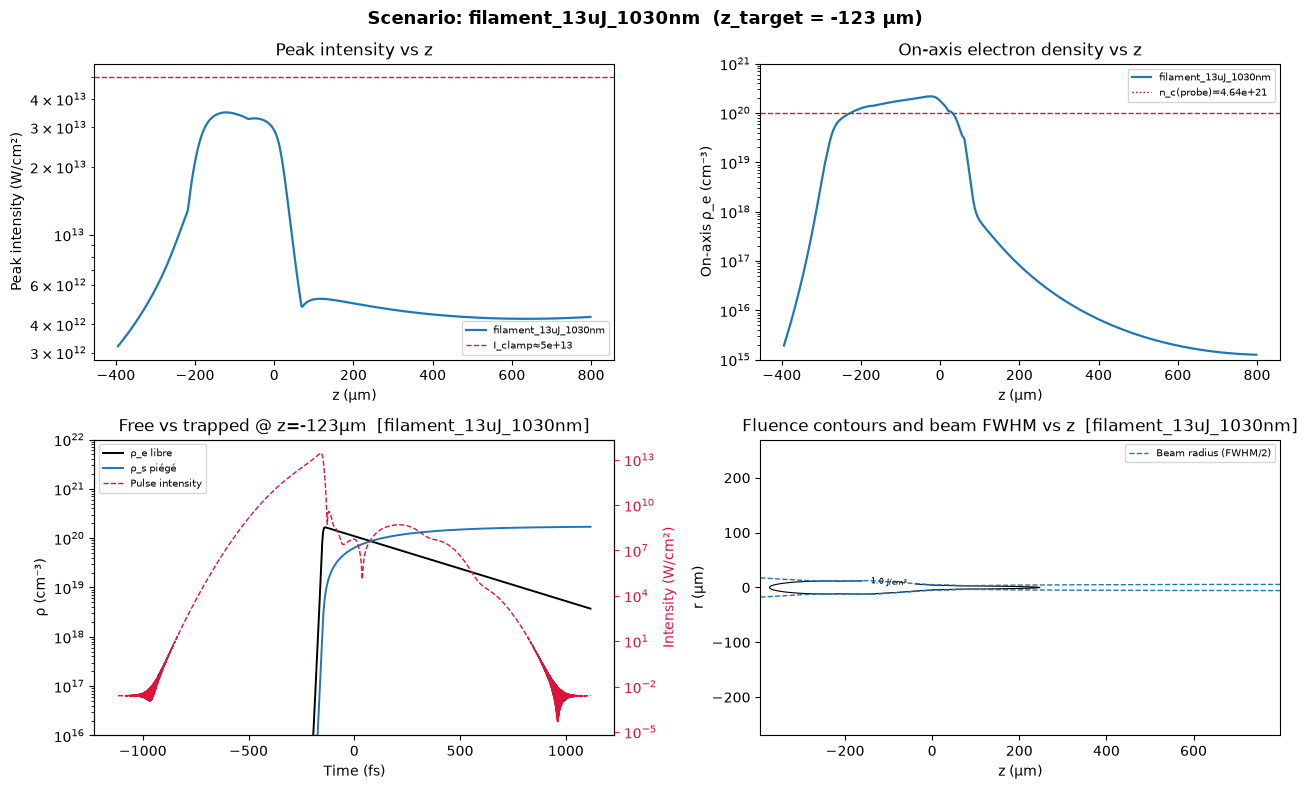

In [7]:
NC_PROBE = epsilon_0*m_e*(2*np.pi*c_SI/LAMBDA_PROBE_M)**2/q_e**2*1e-6
plot_scenario_summary(res, "filament_13uJ_1030nm",
                      nc_probe_cm3=NC_PROBE,
                      rho_lines=(1e20, RHO_MAX_CM3),
                      fluence_levels=(1., 5., 20.),
                      save=str(FIG_DIR/"summary_1030nm.png"));

## 6. Fluence -- cycles de focalisation / défocalisation

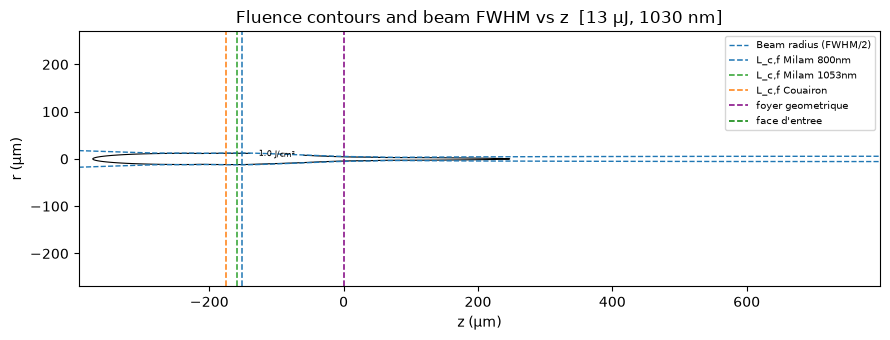

In [8]:
plot_fig7_fluence_contours(res, levels=(1., 2., 5., 10., 20.),
                           label="13 µJ, 1030 nm", vlines=VLINES,
                           save=str(FIG_DIR/"fluence_contours_1030nm.png"));

## 7. Intensité crête -- L_c,f prédite vs collapse observé

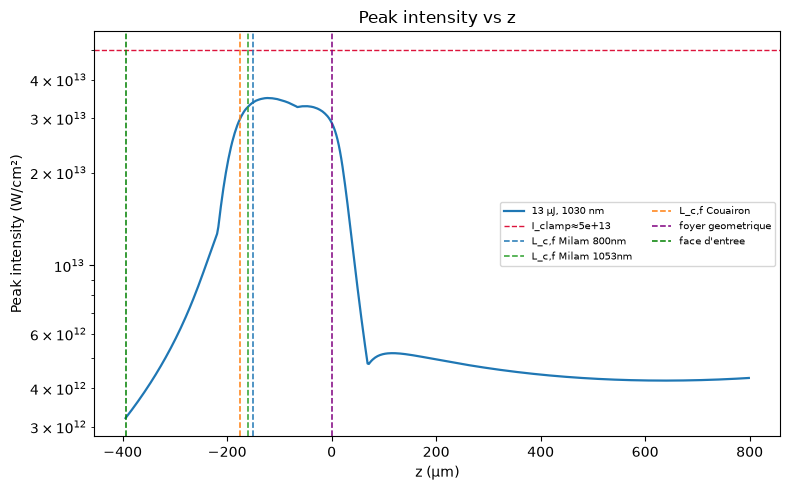

In [9]:
fig = plot_fig8_peak_intensity({"13 µJ, 1030 nm": res})
ax = fig.axes[0]
for zv, lab, col in VLINES:
    ax.axvline(zv, ls="--", lw=1.1, color=col, label=lab)
ax.legend(fontsize=7, ncol=2)
fig.savefig(FIG_DIR/"peak_intensity_vs_Lc_1030nm.png", dpi=150)

## 8. Électrons libres et excitons auto-piégés

Deux vues complémentaires : le long de `z` (maximum temporel), puis en
fonction du **temps** au foyer non-linéaire.

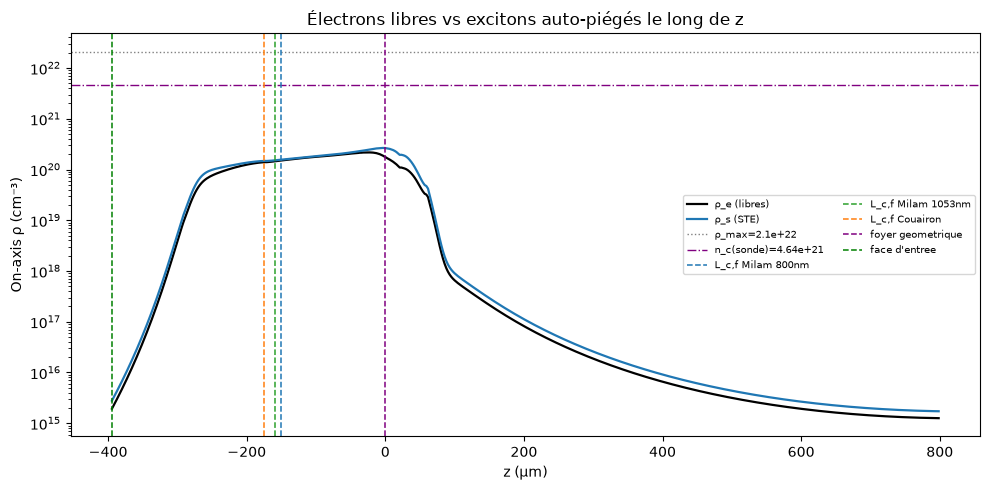

In [10]:
plot_free_vs_trapped_vs_z(res, rho_max_cm3=RHO_MAX_CM3, nc_probe_cm3=NC_PROBE,
                          vlines=VLINES,
                          save=str(FIG_DIR/"rho_e_rho_s_vs_z_1030nm.png"));

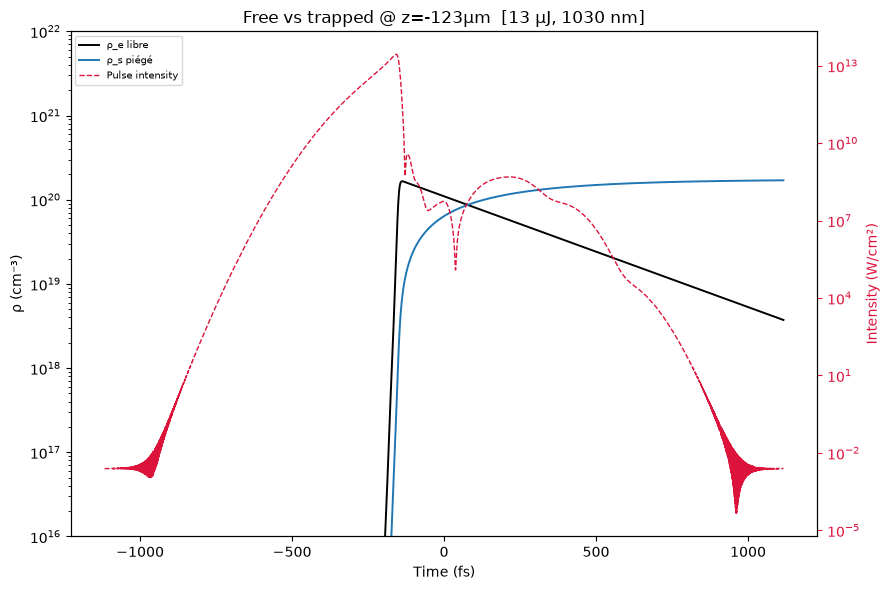

In [11]:
plot_fig13_free_vs_trapped(res, label="13 µJ, 1030 nm",
                           save=str(FIG_DIR/"free_vs_trapped_vs_t_1030nm.png"));

## 9. Pertes d'énergie

Impossible avec `NewSim3juillet.py` (tableaux jamais remplis), disponible ici.

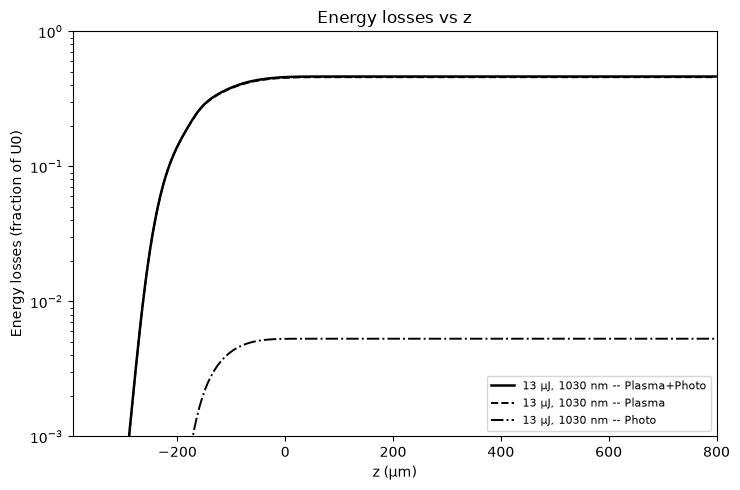

In [12]:
plot_fig12_energy_losses(res, label="13 µJ, 1030 nm",
                         xlim=(BEGIN_M*1e6, END_M*1e6), ylim=(1e-3, 1e0),
                         save=str(FIG_DIR/"energy_losses_1030nm.png"));

## 10. Comptage des cycles + confrontation à L_c,f

In [13]:
idx, z_cycles = count_refocusing_cycles(res, I_clamp=5e13)
if len(idx):
    z_obs = z_cycles[0]
    print(f"\nPremier collapse OBSERVE a z_sim = {z_obs:+.1f} um")
    for lab, p in PRED.items():
        print(f"  vs {lab:13s}: predit {p['z_pred_um']:+7.1f} um   ecart {z_obs-p['z_pred_um']:+7.1f} um")

0 maximum(aux) local(aux) au-dessus de I_clamp=5e+13 :


## 11. Figures « articles » du dépôt

`figures_article` réintègre l'équation de population 0D à partir de la trace
d'intensité on-axis du run -- utile pour vérifier que le noyau CUDA et le
modèle analytique disent la même chose.

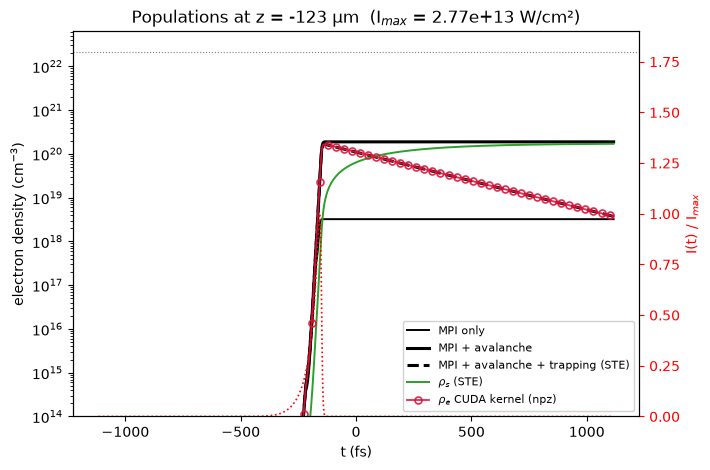

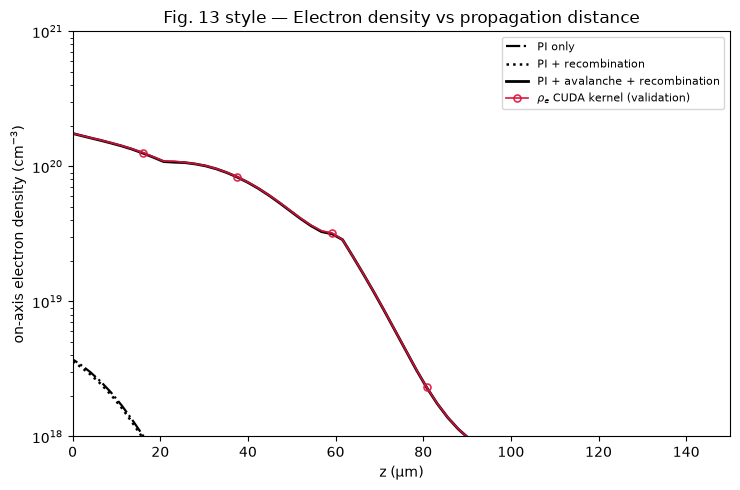

In [14]:
from figures_article import Params as ArticleParams, fig2_populations, fig13_electron_density_vs_z

# Memes constantes que le run, sinon la reintegration 0D diverge du noyau CUDA
# (tau_c en particulier : defaut de Params = 1.7e-15, a re-passer explicitement
# si BASE change un jour).
prm = ArticleParams(
    wavelength=WAVELENGTH_M, Ui_eV=UI_EV, Us_eV=US_EV, meff_rel=MEFF_REL,
    tau_c=TAU_C_S, tau_r=TAU_R_S, rho_max=RHO_MAX_CM3,
    n2=N2_CHOSEN, lambda_probe=LAMBDA_PROBE_M,
)
fig2_populations(res, prm, save=str(FIG_DIR/"fig2_populations_1030nm.png"))
fig13_electron_density_vs_z(res, prm, save=str(FIG_DIR/"fig13_density_vs_z_1030nm.png"));

## 12. Diagnostic : pourquoi le déphasage sonde est-il trop fort ?

Mesure expérimentale : **max ≈ 0.2 rad**. Si la simulation donne plusieurs
radians, il faut savoir **quel canal** est responsable avant de toucher quoi
que ce soit. `decompose_probe_phase` sépare Drude / STE / Kerr et fait
l'intégration d'Abel sur chacun.

Attention à la lecture : la fonction part des cartes 2D (`rho_rz`,
`rho_s_rz`, `Ipeak_rz`) qui sont des **maxima sur le temps**. C'est donc une
**borne supérieure**, et les canaux ne culminent pas au même instant — le
Kerr n'existe que pendant l'impulsion, le STE monte après. Le but est de
répondre à « qui peut faire plusieurs radians », pas de reproduire un délai.

Trois causes candidates, cumulables, par ordre d'impact décroissant :

**(a) Emballement de ρ_e vers ρ_max.** À 12.5 µJ on est à P/P_cr ≈ 11, très
loin du cas Couairon 1.1 µJ qui a servi à valider le solveur. Si ρ_e approche
2.1e22, ce n'est plus du clampage mais de l'emballement, et Δn_STE peut
atteindre 0.88 — soit >100 rad. La cellule le signale explicitement.

**(b) Les STE ne décroissent jamais.** `Config.tau_ste = None` par défaut →
`inv_tau_ste = 0` dans `kernels.py` (l. 86), donc après l'impulsion les STE
ne partent que par ré-ionisation laser, c'est-à-dire plus du tout : ρ_s reste
**gelé indéfiniment**. Or le commentaire de `Config` cite lui-même Sakurai
et al. (~1 ps pour la silice). Ton balayage va jusqu'à +1273 fs, où il ne
devrait rester que 28 % des STE → **surestimation ×3.6** à ce délai.

**(c) Incohérence sur la résonance Lorentz du STE, entre tes propres
fichiers.** `unified_filament_slider_v3.py` utilise `STE_LEVEL_EV = 5.8`
(f_STE = 0.235) ; le dépôt utilise `E_tr_eV = 4.2` (f_STE = 0.570), soit
**×2.42**. Les deux ne peuvent pas être justes. Le docstring de
`figures_article.Params` argumente pour 4.2 eV (Mao et al. : « resonance
frequency of the STE's first excited level (~4.2 eV) »), en expliquant que
les 5.2 eV souvent cités sont le *sommet de la bande d'absorption*, pas la
résonance à utiliser pour l'indice. Je n'ai pas tranché — mais tant que les
deux fichiers divergent, tu compares deux modèles différents.

(b) et (c) combinés font déjà **×8.7** avant même de regarder ρ_s.

In [ ]:
d = decompose_probe_phase(
    res,
    lambda_probe_m=LAMBDA_PROBE_M,
    E_tr_eV=4.2,              # convention du depot ; mettre 5.8 pour celle du slider
    n2=N2_CHOSEN,
    rho_max_cm3=RHO_MAX_CM3,
)

print("\n--- meme calcul avec la convention du slider (5.8 eV) ---")
d58 = decompose_probe_phase(res, lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=5.8,
                            n2=N2_CHOSEN, rho_max_cm3=RHO_MAX_CM3, verbose=False)
for k in d:
    if k in ("x_um", "phi_xz"):
        continue
    print(f"  {k:32s} 4.2eV: {d[k][1]:7.2f} rad   |   5.8eV: {d58[k][1]:7.2f} rad")

print("\nMesure experimentale : max ~0.2 rad")

### Si (a) est confirmé (ρ_e proche de ρ_max)

Le problème n'est pas le STE mais l'ionisation elle-même, et aucun réglage du
canal STE ne le corrigera. Pistes, dans l'ordre :

1. **Vérifier l'énergie réellement lancée** : `[init] U_beam(0)` doit valoir
   12.56 µJ. S'il affiche 13.4 µJ, la correction gaussienne a été appliquée
   deux fois dans le mauvais sens.
2. **Vérifier `w0`.** 3 µm est le waist *mesuré au foyer côté air*. S'il est
   surestimé, l'intensité l'est aussi — et l'ionisation varie comme `I^8` à
   1030 nm, donc 20 % d'erreur sur w0 fait un facteur ~4 sur ρ_e.
3. **Comparer à `enable_avalanche=False`** : si ρ_e chute d'un ordre de
   grandeur, c'est l'avalanche qui s'emballe, et `tau_c` (qui fixe
   `beta_g = sigma/Ui`) est le paramètre à interroger — rappel : le dépôt
   utilise 1.7 fs (ω₀τ_c = 3.1, convention Bulgakova) là où Couairon prend
   1e-14 s (ω₀τ_c = 23.6).

### Relance avec décroissance STE activée

Un seul paramètre à ajouter (`tau_ste`), tout le reste identique — à comparer
au run de référence plutôt qu'à le remplacer.

In [ ]:
# Relance avec decroissance STE (Sakurai et al. ~1 ps), pour isoler l'effet (b).
# NE PAS ecraser le run de reference : autre out_dir, on compare les deux.
OUT_DIR_STE = str(OUT_ROOT / "filament_13uJ_w3um_tau_ste_1ps")

res_ste = load_scenario_npz(OUT_DIR_STE)
if res_ste is None:
    print(f"Lancement -> {OUT_DIR_STE}")
    res_ste = run(
        Nz=NZ, Nt=NT, Nr=NR, R_factor=R_FACTOR, end=END_M,
        z_focus_air_um=Z_FOCUS_AIR_UM,
        save_stride=SAVE_STRIDE, ckpt_every=500, verbose=True,
        wavelength=WAVELENGTH_M, energy_uJ=ENERGY_IN_GLASS,
        w0=W0_M, delta_t=DELTA_T_S,
        n2=N2_CHOSEN, Ui_eV=UI_EV, meff_rel=MEFF_REL,
        tau_c=TAU_C_S, tau_r=TAU_R_S, rho_max=RHO_MAX_CM3,
        Us_eV=US_EV, f_R=F_R, tau_d=TAU_D_S, tau_s=TAU_S_S,
        enable_ste=True,
        tau_ste=1e-12,                     # <-- LA SEULE difference
        lambda_probe=LAMBDA_PROBE_M,
        rho_t_stride=RHO_T_STRIDE, rho_r_stride=RHO_R_STRIDE,
        out_dir=OUT_DIR_STE, envelope="gaussian_focused",
    )

print("\n=== sans decroissance STE ===")
_ = decompose_probe_phase(res, lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=4.2,
                          n2=N2_CHOSEN, rho_max_cm3=RHO_MAX_CM3)
print("\n=== avec tau_ste = 1 ps ===")
_ = decompose_probe_phase(res_ste, lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=4.2,
                          n2=N2_CHOSEN, rho_max_cm3=RHO_MAX_CM3)

## 13. Récapitulatif pour `main.tex`

In [15]:
print("Figures ->", FIG_DIR.resolve())
for f in sorted(FIG_DIR.glob("*.png")): print("  -", f.name)

z_um = z_um_of(res); Imax = np.asarray(res["Imax_z"]); ia = onaxis_index(res)
print(f"\n1030 nm | {ENERGY_INPUT_UJ} uJ incident -> {ENERGY_IN_GLASS:.2f} uJ dans le verre")
print(f"w0(foyer)={W0_M*1e6:.1f} um | w(entree)={W_ENTRANCE_M*1e6:.1f} um | FWHM={DELTA_T_S*1e15:.0f} fs")
print(f"n2={N2_CHOSEN:.2e} m2/W -> P_cr={PRED['Milam 1053nm']['P_cr']*1e-6:.2f} MW, "
      f"P_in/P_cr={PRED['Milam 1053nm']['ratio']:.1f}")
print(f"I_max={Imax.max():.3e} W/cm2 @ z={z_um[np.argmax(Imax)]:+.1f} um")
print(f"rho_e max={res['rho_rz'][:,ia].max():.3e} cm-3 | rho_s max={res['rho_s_rz'][:,ia].max():.3e} cm-3")
print(f"pertes totales={np.max(res['E_total_z'])*100:.1f} %")
print(f"{len(idx)} cycle(s) detecte(s)")

Figures -> /workspace/notebooks/runs_1030nm/figures_for_report
  - energy_losses_1030nm.png
  - fig13_density_vs_z_1030nm.png
  - fig2_populations_1030nm.png
  - fluence_contours_1030nm.png
  - free_vs_trapped_vs_t_1030nm.png
  - peak_intensity_vs_Lc_1030nm.png
  - rho_e_rho_s_vs_z_1030nm.png
  - summary_1030nm.png

1030 nm | 13.0 uJ incident -> 12.56 uJ dans le verre
w0(foyer)=3.0 um | w(entree)=29.9 um | FWHM=263 fs
n2=2.74e-20 m2/W -> P_cr=4.01 MW, P_in/P_cr=11.2
I_max=3.487e+13 W/cm2 @ z=-123.2 um
rho_e max=2.173e+20 cm-3 | rho_s max=2.661e+20 cm-3
pertes totales=46.3 %
0 cycle(s) detecte(s)


In [21]:
# ================= Abel phase explorer -- run 1030 nm =================
# sim/ et web/ sont deja sur sys.path (cellule d'imports)
from abel_phase_explorer import build_explorer_html

sim_dirs = {"13uJ_1030nm": OUT_DIR}   # OUT_DIR = runs_1030nm/filament_13uJ_w3um (cellule 9)

build_explorer_html(
    sim_dirs=sim_dirs,
    save=str(FIG_DIR / "abel_phase_explorer_1030nm.html"),
    raw_dir=None,        # chemin vers tes npz bruts (side_sig/side_bg) pour activer le panneau experience
    energy_uJ=ENERGY_INPUT_UJ,   # 13.0, sert a chercher le bon fichier brut dans raw_dir
    lmd_nm=LAMBDA_PROBE_M * 1e9, # 490 nm, deja coherent avec le defaut de la fonction
    pmin=-20, pmax=19, fs_per_pulse=67.0,   # balayage des retards -- a ajuster si ton scan est different
)
print("-> ouvre", FIG_DIR / "abel_phase_explorer_1030nm.html", "dans un navigateur")

[13uJ_1030nm] 40 pulses depuis runs_1030nm/filament_13uJ_w3um
-> Sauvegardé : runs_1030nm/figures_for_report/abel_phase_explorer_1030nm.html  (232.3 MB)
-> ouvre runs_1030nm/figures_for_report/abel_phase_explorer_1030nm.html dans un navigateur


/tmp/ipykernel_568/1878998239.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(z_um, r_sym, F_sym.T, shading="auto",


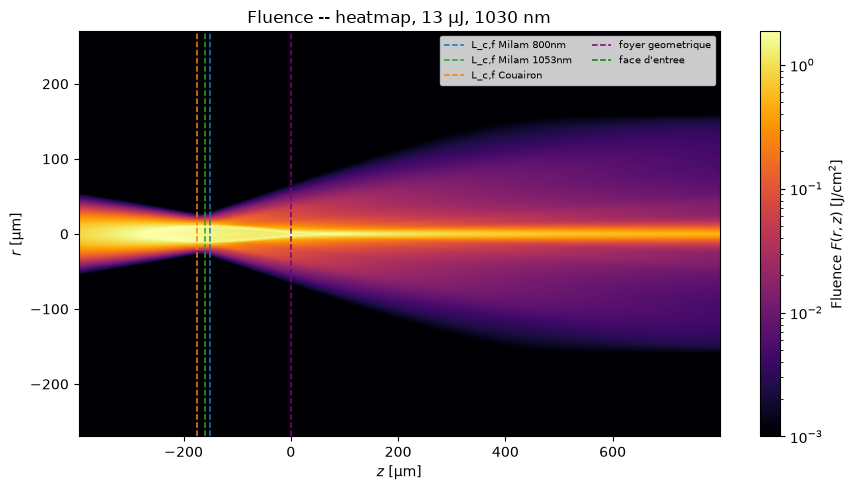

In [18]:
# ================= Fluence max -- heatmap (log, vue continue) =================
from matplotlib.colors import LogNorm

z_um = z_um_of(res)                                          # (n_saves,)
r_um = res["r"] * 1e6                                        # (Nr-1,), grille radiale complète

F_key = "fluence_rz" if "fluence_rz" in res else next(k for k in res.keys() if "fluence" in k.lower())
F = np.asarray(res[F_key])                                   # (n_saves, Nr-1), J/cm^2

# vue symetrique -r..+r (la physique est cylindrique, purement esthetique)
r_sym = np.concatenate([-r_um[::-1], r_um])
F_sym = np.concatenate([F[:, ::-1], F], axis=1)               # (n_saves, 2*(Nr-1))

fig, ax = plt.subplots(figsize=(9, 5))
vmin = max(F_sym[F_sym > 0].min(), 1e-3)                      # evite log(0)
pcm = ax.pcolormesh(z_um, r_sym, F_sym.T, shading="auto",
                     cmap="inferno", norm=LogNorm(vmin=vmin, vmax=F_sym.max()))
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"Fluence $F(r,z)$ [J/cm$^2$]")

for zv, lab, col in VLINES:
    ax.axvline(zv, ls="--", lw=1.1, color=col, label=lab)
ax.legend(fontsize=7, ncol=2, loc="upper right")

ax.set_xlabel(r"$z$ [µm]"); ax.set_ylabel(r"$r$ [µm]")
ax.set_title("Fluence -- heatmap, 13 µJ, 1030 nm")
fig.tight_layout()
fig.savefig(FIG_DIR / "fluence_heatmap_1030nm.png", dpi=150)